In [15]:
!jupyter nbconvert --to script zernike.ipynb
!jupyter nbconvert --to script phase_screen.ipynb
!jupyter nbconvert --to script reconstruction.ipynb

[NbConvertApp] Converting notebook zernike.ipynb to script
[NbConvertApp] Writing 9303 bytes to zernike.py
[NbConvertApp] Converting notebook phase_screen.ipynb to script
[NbConvertApp] Writing 3716 bytes to phase_screen.py
[NbConvertApp] Converting notebook reconstruction.ipynb to script
[NbConvertApp] Writing 7481 bytes to reconstruction.py


In [8]:
import importlib

import zernike
import phase_screen
import reconstruction

importlib.reload(zernike)
importlib.reload(phase_screen)
importlib.reload(reconstruction)

In [ ]:
#Test1: Fixed Low-Order Aberration Wavefront

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from zernike import (
    make_pupil_grid,
    zernike_named_modes,
    synthesize_wavefront,
)

from reconstruction import (
    build_response_matrix,
    measure_slopes,
    reconstruct_wavefront,
    residual_wavefront,
    rms,
)

In [10]:
# -------------------------
# 1. Parameters
# -------------------------
N = 256
diameter = 1.0
n_lenslets = 12

# -------------------------
# 2. Pupil grid
# -------------------------
X, Y, rho, theta, mask, dx = make_pupil_grid(
    N=N,
    diameter=diameter,
)

# -------------------------
# 3. Zernike-like modes
# -------------------------
modes = zernike_named_modes(
    rho,
    theta,
    mask,
    include_piston=False,
    normalized=True,
)

# -------------------------
# 4. Fixed deterministic wavefront
# -------------------------
true_coeffs = {
    "tip_x": 0.05,
    "tip_y": -0.03,
    "defocus": 0.25,
    "astig_45": -0.12,
    "astig_0": 0.08,
    "coma_x": 0.10,
    "coma_y": -0.07,
    "spherical": 0.04,
}

W_true = synthesize_wavefront(
    modes,
    true_coeffs,
    mask,
    remove_mean=True,
)

# -------------------------
# 5. Shack-Hartmann measurement
# -------------------------
centers, slopes = measure_slopes(
    W_true,
    mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=0.5,
    noise_std=0.0,
)

# -------------------------
# 6. Response matrix
# -------------------------
A, names, _ = build_response_matrix(
    modes,
    mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=0.5,
)

# -------------------------
# 7. Reconstruct wavefront
# -------------------------
coeffs, W_rec, residuals, rank, singular_values = reconstruct_wavefront(
    slopes,
    A,
    modes,
    names,
    mask,
    rcond=1e-4,
)

res = residual_wavefront(W_true, W_rec, mask)

# -------------------------
# 8. Print diagnostics
# -------------------------
print("Estimated coefficients")
print("----------------------")

for name, coeff in zip(names, coeffs):
    true_value = true_coeffs.get(name, 0.0)
    print(f"{name:12s}: true = {true_value:+.4f}, estimated = {coeff:+.4f}")

print()
print(f"Response matrix rank: {rank}")
print(f"True wavefront RMS:   {rms(W_true, mask):.4e}")
print(f"Residual RMS:         {rms(res, mask):.4e}")

Estimated coefficients
----------------------
tip_x       : true = +0.0500, estimated = +0.0500
tip_y       : true = -0.0300, estimated = -0.0300
defocus     : true = +0.2500, estimated = +0.2500
astig_45    : true = -0.1200, estimated = -0.1200
astig_0     : true = +0.0800, estimated = +0.0800
coma_x      : true = +0.1000, estimated = +0.1000
coma_y      : true = -0.0700, estimated = -0.0700
trefoil_x   : true = +0.0000, estimated = +0.0000
trefoil_y   : true = +0.0000, estimated = -0.0000
spherical   : true = +0.0400, estimated = +0.0400

Response matrix rank: 10
True wavefront RMS:   3.2096e-01
Residual RMS:         4.5609e-05


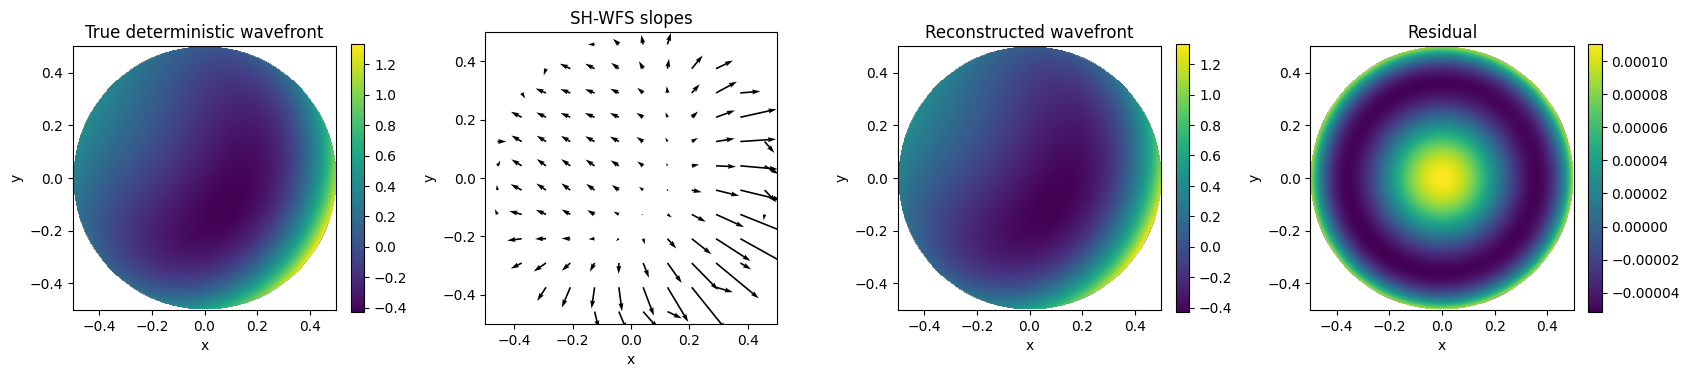

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

im0 = axes[0].imshow(
    W_true,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
)
axes[0].set_title("True deterministic wavefront")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].quiver(
    centers[:, 0],
    centers[:, 1],
    slopes[:, 0],
    slopes[:, 1],
)
axes[1].set_title("SH-WFS slopes")
axes[1].set_aspect("equal")
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_ylim(-0.5, 0.5)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

im2 = axes[2].imshow(
    W_rec,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
)
axes[2].set_title("Reconstructed wavefront")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(
    res,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
)
axes[3].set_title("Residual")
axes[3].set_xlabel("x")
axes[3].set_ylabel("y")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()

In [ ]:
#Test2: Random atmospheric turbulent wavefront

In [12]:
from phase_screen import fourier_phase_screen

In [13]:
# -------------------------
# 1. Parameters
# -------------------------
N = 256
diameter = 1.0
n_lenslets = 14
r0 = 0.20

# -------------------------
# 2. Pupil grid
# -------------------------
X, Y, rho, theta, mask, dx = make_pupil_grid(
    N=N,
    diameter=diameter,
)

# -------------------------
# 3. Random atmospheric phase screen
# -------------------------
W_atm, _, _, _ = fourier_phase_screen(
    N=N,
    delta=dx,
    r0=r0,
    L0=25.0,
    diameter=diameter,
    seed=4,
    target_rms_rad=1.0,
)

# -------------------------
# 4. Zernike-like reconstruction basis
# -------------------------
modes = zernike_named_modes(
    rho,
    theta,
    mask,
    include_piston=False,
    normalized=True,
)

# -------------------------
# 5. SH-WFS measurement
# -------------------------
centers, slopes = measure_slopes(
    W_atm,
    mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=0.5,
    noise_std=0.01,
    seed=2,
)

# -------------------------
# 6. Response matrix
# -------------------------
A, names, _ = build_response_matrix(
    modes,
    mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=0.5,
)

# -------------------------
# 7. Reconstruct low-order wavefront
# -------------------------
coeffs, W_rec, residuals, rank, singular_values = reconstruct_wavefront(
    slopes,
    A,
    modes,
    names,
    mask,
    rcond=1e-4,
)

res = residual_wavefront(W_atm, W_rec, mask)

print("Low-order modal coefficients")
print("----------------------------")

for name, coeff in zip(names, coeffs):
    print(f"{name:12s}: {coeff:+.4f}")

print()
print(f"Response matrix rank: {rank}")
print(f"Input atmospheric RMS: {rms(W_atm, mask):.4f} rad")
print(f"Residual RMS:          {rms(res, mask):.4f} rad")

Low-order modal coefficients
----------------------------
tip_x       : -0.2378
tip_y       : -0.6963
defocus     : +0.1723
astig_45    : +0.3108
astig_0     : -0.3684
coma_x      : +0.1599
coma_y      : +0.0359
trefoil_x   : +0.2494
trefoil_y   : -0.3371
spherical   : -0.0135

Response matrix rank: 10
Input atmospheric RMS: 0.9999 rad
Residual RMS:          0.6724 rad


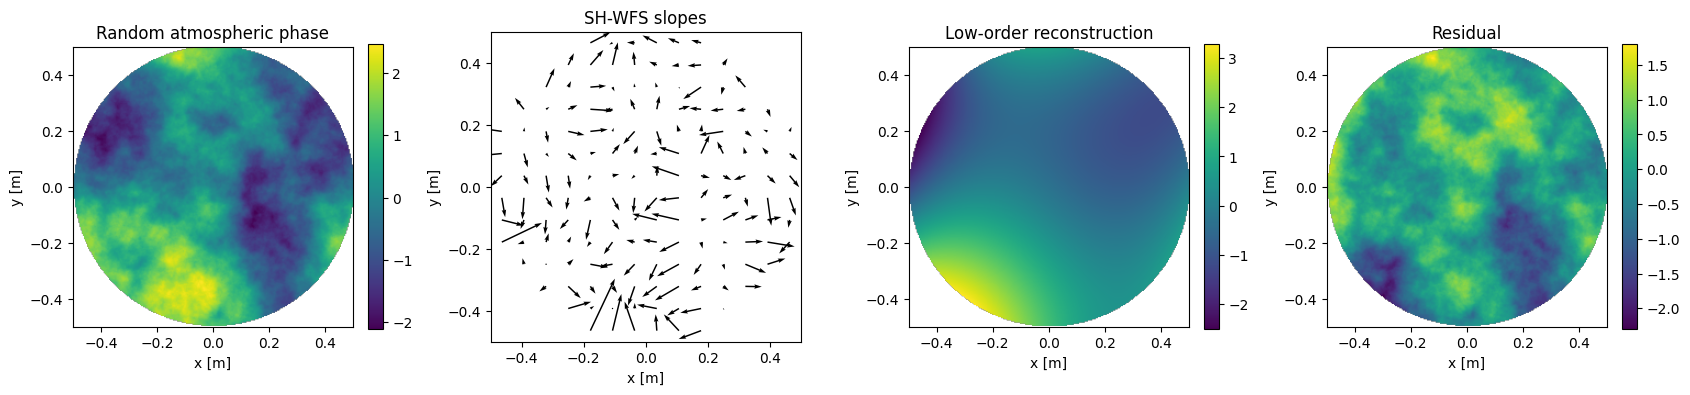

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

im0 = axes[0].imshow(
    W_atm,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
)
axes[0].set_title("Random atmospheric phase")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].quiver(
    centers[:, 0],
    centers[:, 1],
    slopes[:, 0],
    slopes[:, 1],
)
axes[1].set_title("SH-WFS slopes")
axes[1].set_aspect("equal")
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_ylim(-0.5, 0.5)
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")

im2 = axes[2].imshow(
    W_rec,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
)
axes[2].set_title("Low-order reconstruction")
axes[2].set_xlabel("x [m]")
axes[2].set_ylabel("y [m]")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(
    res,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
)
axes[3].set_title("Residual")
axes[3].set_xlabel("x [m]")
axes[3].set_ylabel("y [m]")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()